<a href="https://colab.research.google.com/github/Moysezg/financial-risk-management-var-models/blob/main/04_garch_dynamic_var.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.1 MB/s eta 0:00:00


/tmp/ipykernel_557/3275686255.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_raw = yf.download(ticker_simbolo, start=fecha_retroceso, end=fecha_actual, interval="1d")
[*********************100%***********************]  1 of 1 completed


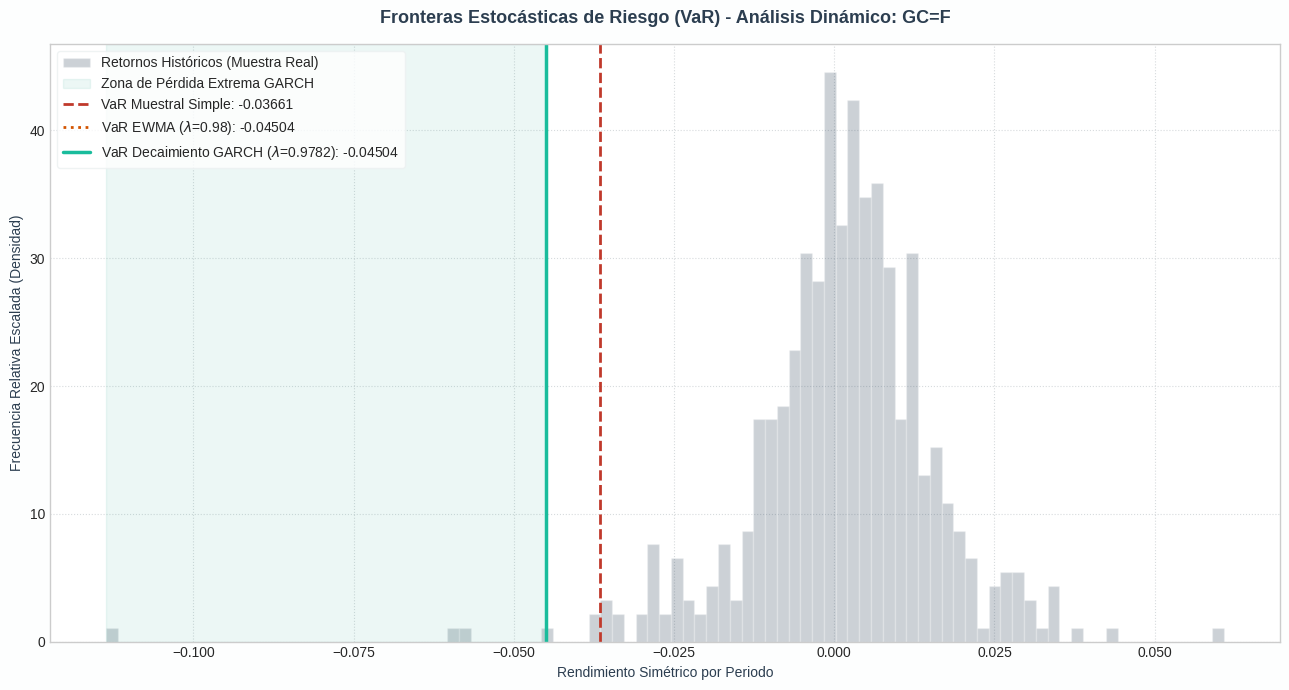


■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
 METRIC CONSOLIDATION - VOLATILITY DECAY KERNEL
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
 » VaR Histórico Puro (Equiponderado)   : -0.036609
 » VaR EWMA Estándar (Factor Fijo 0.98) : -0.045042
 » VaR Ponderado Dinámico (GARCH)        : -0.045042 [λ_opt: 0.9782]
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■



In [ ]:
# 1. Instalación automática de dependencias en el entorno
!pip install arch yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from arch import arch_model
from typing import Tuple, Dict

def obtener_rendimientos_mercado(ticker_simbolo: str, horizonte_anios: int) -> np.ndarray:
    """Descarga datos históricos y extrae el vector de rendimientos aritméticos."""
    fecha_actual = datetime.now()
    fecha_retroceso = fecha_actual - timedelta(days=horizonte_anios * 365)

    data_raw = yf.download(ticker_simbolo, start=fecha_retroceso, end=fecha_actual, interval="1d")
    if data_raw.empty:
        raise ValueError(f"No se encontraron registros disponibles para: {ticker_simbolo}")

    precios_cierre = data_raw['Close'].dropna().values.flatten()
    return (precios_cierre[1:] - precios_cierre[:-1]) / precios_cierre[:-1]

def determinar_pesos_garch(rendimientos: np.ndarray) -> Tuple[float, np.ndarray]:
    """Ajusta un modelo GARCH(1,1) para extraer la persistencia (lambda dinámico)."""
    garch_spec = arch_model(rendimientos * 100, vol='Garch', p=1, q=1, dist='Normal')
    garch_fitted = garch_spec.fit(disp='off')

    param_alpha = garch_fitted.params['alpha[1]']
    param_beta = garch_fitted.params['beta[1]']

    lambda_dinamico = param_alpha + param_beta
    if lambda_dinamico >= 1.0:
        lambda_dinamico = 0.995

    n_observaciones = len(rendimientos)
    pesos_temporales = np.array([lambda_dinamico**(n_observaciones - t - 1) for t in range(n_observaciones)])
    pesos_temporales /= np.sum(pesos_temporales)

    return float(lambda_dinamico), pesos_temporales

def calcular_umbrales_var(rendimientos: np.ndarray, pesos_garch: np.ndarray, alfa: float) -> Dict[str, float]:
    """Computa el VaR clásico y las variantes ponderadas por decaimiento exponencial."""
    n_obs = len(rendimientos)

    # 1. VaR Histórico Equiponderado
    var_class = float(np.percentile(rendimientos, alfa * 100))

    # 2. VaR GARCH Ponderado
    df_garch = pd.DataFrame({'r': rendimientos, 'w': pesos_garch}).sort_values('r')
    df_garch['w_cum'] = df_garch['w'].cumsum()
    var_garch_val = df_garch[df_garch['w_cum'] >= alfa]['r'].iloc[0]

    # 3. VaR EWMA Estándar (Lambda Fijo = 0.98)
    pesos_ewma = np.array([0.98**(n_obs - t - 1) for t in range(n_obs)])
    pesos_ewma /= np.sum(pesos_ewma)
    df_ewma = pd.DataFrame({'r': rendimientos, 'w': pesos_ewma}).sort_values('r')
    df_ewma['w_cum'] = df_ewma['w'].cumsum()
    var_ewma_val = df_ewma[df_ewma['w_cum'] >= alfa]['r'].iloc[0]

    return {"historico": var_class, "garch": var_garch_val, "ewma_fijo": var_ewma_val}

def graficar_perfil_riesgo(rendimientos: np.ndarray, pesos_garch: np.ndarray, metricas: Dict[str, float], lambda_garch: float, activo: str):
    """Genera la interfaz gráfica comparativa usando densidades y líneas de umbral."""
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(13, 7), facecolor='#fdfefe')
    ax.set_facecolor('#ffffff')

    # Histograma representativo del mercado
    ax.hist(rendimientos, bins=95, density=True, color='#34495e', edgecolor='#ffffff', alpha=0.25, label='Retornos Históricos (Muestra Real)')

    # Sombreado de la cola izquierda
    ax.axvspan(min(rendimientos), metricas["garch"], color='#16a085', alpha=0.08, label='Zona de Pérdida Extrema GARCH')

    # Líneas de demarcación técnica (Uso de rf"..." para evitar advertencias de sintaxis con \lambda)
    ax.axvline(metricas["historico"], color='#c0392b', linestyle='--', linewidth=2.0,
               label=f'VaR Muestral Simple: {metricas["historico"]:.5f}')

    ax.axvline(metricas["ewma_fijo"], color='#d35400', linestyle=':', linewidth=2.0,
               label=rf'VaR EWMA ($\lambda$=0.98): {metricas["ewma_fijo"]:.5f}')

    ax.axvline(metricas["garch"], color='#1abc9c', linestyle='-', linewidth=2.5,
               label=rf'VaR Decaimiento GARCH ($\lambda$={lambda_garch:.4f}): {metricas["garch"]:.5f}')

    ax.set_title(f"Fronteras Estocásticas de Riesgo (VaR) - Análisis Dinámico: {activo}", fontsize=13, fontweight='bold', color='#2c3e50', pad=15)
    ax.set_xlabel("Rendimiento Simétrico por Periodo", fontsize=10, color='#2c3e50')
    ax.set_ylabel("Frecuencia Relativa Escalada (Densidad)", fontsize=10, color='#2c3e50')

    ax.grid(True, linestyle=':', alpha=0.6, color='#bdc3c7')
    ax.legend(loc='upper left', frameon=True, facecolor='#ffffff', edgecolor='#ecf0f1')

    plt.tight_layout()
    plt.show()

# Execution Launcher
if __name__ == "__main__":
    ACTIVO = "GC=F"
    ANIO_VENTANA = 2
    ALFA_CONFIANZA = 0.01

    try:
        series_rendimientos = obtener_rendimientos_mercado(ticker_simbolo=ACTIVO, horizonte_anios=ANIO_VENTANA)
        decay_garch, vectores_ponderacion = determinar_pesos_garch(rendimientos=series_rendimientos)

        resultados_var = calcular_umbrales_var(
            rendimientos=series_rendimientos,
            pesos_garch=vectores_ponderacion,
            alfa=ALFA_CONFIANZA
        )

        graficar_perfil_riesgo(
            rendimientos=series_rendimientos,
            pesos_garch=vectores_ponderacion,
            metricas=resultados_var,
            lambda_garch=decay_garch,
            activo=ACTIVO
        )

        print("\n" + "■"*80)
        print(f" METRIC CONSOLIDATION - VOLATILITY DECAY KERNEL")
        print("■"*80)
        print(f" » VaR Histórico Puro (Equiponderado)   : {resultados_var['historico']:.6f}")
        print(f" » VaR EWMA Estándar (Factor Fijo 0.98) : {resultados_var['ewma_fijo']:.6f}")
        print(f" » VaR Ponderado Dinámico (GARCH)        : {resultados_var['garch']:.6f} [λ_opt: {decay_garch:.4f}]")
        print("■"*80 + "\n")

    except Exception as error_ejecucion:
        print(f"Fallo operacional en el cálculo del pipeline: {error_ejecucion}")